In [35]:
# ============================================================
# 1. SETUP
# ============================================================

import os
import glob
import zipfile
import shutil
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive

drive.mount('/content/drive')

print("Setup complete")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete


In [36]:
# ============================================================
# 2. KAGGLE SETUP
# ============================================================

!pip install -q kaggle

os.makedirs("/root/.kaggle", exist_ok=True)

# Upload kaggle.json when prompted
from google.colab import files

uploaded = files.upload()

shutil.copy(
    list(uploaded.keys())[0],
    "/root/.kaggle/kaggle.json"
)

os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("Kaggle API configured")

Saving kaggle.json to kaggle (2).json
Kaggle API configured


In [37]:
# ============================================================
# 3. DOWNLOAD BIOIMLAB DATASET
# ============================================================

!rm -rf /content/biolm_dataset
!mkdir -p /content/biolm_dataset

!kaggle datasets download \
    -d arifmpthesis/bioimlab-chromosome-data-set-for-classification \
    -p /content/biolm_dataset

print("\nDownloaded files:")
!ls -lh /content/biolm_dataset

Dataset URL: https://www.kaggle.com/datasets/arifmpthesis/bioimlab-chromosome-data-set-for-classification
License(s): other
100% 10.7M/10.7M [00:00<00:00, 93.7MB/s]


Downloaded files:
total 11M
-rw-r--r-- 1 root root 11M Aug 28  2024 bioimlab-chromosome-data-set-for-classification.zip


In [38]:
# ============================================================
# 4. EXTRACT DATASET
# ============================================================

zip_files = glob.glob("/content/biolm_dataset/*.zip")

print("ZIP files found:")
for z in zip_files:
    print(z)

if len(zip_files) == 0:
    raise FileNotFoundError("No Kaggle ZIP file found.")

for zip_file in zip_files:
    print("\nExtracting:", zip_file)

    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall("/content/biolm_dataset/extracted")

print("\nExtraction completed.")

ZIP files found:
/content/biolm_dataset/bioimlab-chromosome-data-set-for-classification.zip

Extracting: /content/biolm_dataset/bioimlab-chromosome-data-set-for-classification.zip

Extraction completed.


In [39]:
# ============================================================
# 5. INSPECT EXTRACTED DATASET STRUCTURE
# ============================================================

root = "/content/biolm_dataset/extracted"

for current_root, dirs, files in os.walk(root):
    level = current_root.replace(root, "").count(os.sep)

    if level <= 3:
        print(
            "  " * level +
            os.path.basename(current_root) +
            f"  | folders={len(dirs)} files={len(files)}"
        )

extracted  | folders=24 files=0
  Class_7  | folders=0 files=238
  Class_15  | folders=0 files=238
  Class_22  | folders=0 files=238
  Class_19  | folders=0 files=238
  Class_18  | folders=0 files=238
  Class_13  | folders=0 files=238
  Class_21  | folders=0 files=238
  Class_4  | folders=0 files=238
  Class_10  | folders=0 files=238
  Class_16  | folders=0 files=238
  Class_20  | folders=0 files=238
  Class_X  | folders=0 files=193
  Class_9  | folders=0 files=238
  Class_12  | folders=0 files=238
  Class_14  | folders=0 files=238
  Class_11  | folders=0 files=238
  Class_5  | folders=0 files=238
  Class_8  | folders=0 files=238
  Class_17  | folders=0 files=238
  Class_2  | folders=0 files=238
  Class_Y  | folders=0 files=45
  Class_3  | folders=0 files=238
  Class_1  | folders=0 files=238
  Class_6  | folders=0 files=238


In [40]:
# ============================================================
# 6. FIND IMAGE FILES
# ============================================================

extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff"]

image_files = []

for ext in extensions:
    image_files.extend(
        glob.glob(root + "/**/" + ext, recursive=True)
    )

print("Total images found:", len(image_files))

print("\nFirst 20 images:")
for img in image_files[:20]:
    print(img)

Total images found: 5474

First 20 images:
/content/biolm_dataset/extracted/Class_7/73 7a.bmp
/content/biolm_dataset/extracted/Class_7/77 7b.bmp
/content/biolm_dataset/extracted/Class_7/42 7a.bmp
/content/biolm_dataset/extracted/Class_7/82 7b.bmp
/content/biolm_dataset/extracted/Class_7/58 7b.bmp
/content/biolm_dataset/extracted/Class_7/35 7b.bmp
/content/biolm_dataset/extracted/Class_7/3 7b.bmp
/content/biolm_dataset/extracted/Class_7/49 7b.bmp
/content/biolm_dataset/extracted/Class_7/85 7a.bmp
/content/biolm_dataset/extracted/Class_7/65 7a.bmp
/content/biolm_dataset/extracted/Class_7/56 7a.bmp
/content/biolm_dataset/extracted/Class_7/62 7b.bmp
/content/biolm_dataset/extracted/Class_7/44 7b.bmp
/content/biolm_dataset/extracted/Class_7/2 7b.bmp
/content/biolm_dataset/extracted/Class_7/16 7b.bmp
/content/biolm_dataset/extracted/Class_7/60 7a.bmp
/content/biolm_dataset/extracted/Class_7/74 7b.bmp
/content/biolm_dataset/extracted/Class_7/15 7b.bmp
/content/biolm_dataset/extracted/Class_7/

In [41]:
# ============================================================
# 7. FIND FOLDERS CONTAINING IMAGES
# ============================================================

folders_with_images = {}

for img in image_files:
    folder = os.path.dirname(img)

    if folder not in folders_with_images:
        folders_with_images[folder] = 0

    folders_with_images[folder] += 1

print("Folders containing images:\n")

for folder, count in folders_with_images.items():
    print(f"{count:5d} images -> {folder}")

Folders containing images:

  238 images -> /content/biolm_dataset/extracted/Class_7
  238 images -> /content/biolm_dataset/extracted/Class_15
  238 images -> /content/biolm_dataset/extracted/Class_22
  238 images -> /content/biolm_dataset/extracted/Class_19
  238 images -> /content/biolm_dataset/extracted/Class_18
  238 images -> /content/biolm_dataset/extracted/Class_13
  238 images -> /content/biolm_dataset/extracted/Class_21
  238 images -> /content/biolm_dataset/extracted/Class_4
  238 images -> /content/biolm_dataset/extracted/Class_10
  238 images -> /content/biolm_dataset/extracted/Class_16
  238 images -> /content/biolm_dataset/extracted/Class_20
  193 images -> /content/biolm_dataset/extracted/Class_X
  238 images -> /content/biolm_dataset/extracted/Class_9
  238 images -> /content/biolm_dataset/extracted/Class_12
  238 images -> /content/biolm_dataset/extracted/Class_14
  238 images -> /content/biolm_dataset/extracted/Class_11
  238 images -> /content/biolm_dataset/extracted

In [42]:
# ============================================================
# 5. LOAD ALL IMAGES FROM BioImLAB DATASET
# ============================================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

dataset_path = "/content/biolm_dataset/extracted"

class_names = sorted(
    [
        d for d in os.listdir(dataset_path)
        if os.path.isdir(os.path.join(dataset_path, d))
    ],
    key=lambda x: (
        100 if x == "Class_X" else
        101 if x == "Class_Y" else
        int(x.split("_")[1])
    )
)

print("Number of classes:", len(class_names))
print("Classes:", class_names)

# ------------------------------------------------------------
# Load images
# ------------------------------------------------------------

images = []
labels = []

IMG_SIZE = 224

for label, class_name in enumerate(class_names):

    class_path = os.path.join(dataset_path, class_name)

    files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    for file in files:

        image_path = os.path.join(class_path, file)

        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            continue

        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

        images.append(image)
        labels.append(label)

images = np.array(images)
labels = np.array(labels)

print("\nImages shape:", images.shape)
print("Labels shape:", labels.shape)
print("Pixel range:", images.min(), "to", images.max())

Number of classes: 24
Classes: ['Class_1', 'Class_2', 'Class_3', 'Class_4', 'Class_5', 'Class_6', 'Class_7', 'Class_8', 'Class_9', 'Class_10', 'Class_11', 'Class_12', 'Class_13', 'Class_14', 'Class_15', 'Class_16', 'Class_17', 'Class_18', 'Class_19', 'Class_20', 'Class_21', 'Class_22', 'Class_X', 'Class_Y']

Images shape: (5474, 224, 224)
Labels shape: (5474,)
Pixel range: 0 to 255


In [43]:
# ============================================================
# 6. CLASS DISTRIBUTION
# ============================================================

unique, counts = np.unique(labels, return_counts=True)

print("\nClass distribution:\n")

for i in range(len(unique)):
    print(
        f"{class_names[unique[i]]:10s} : {counts[i]:4d}"
    )

print("\nTotal images:", len(labels))
print("Minimum class size:", counts.min())
print("Maximum class size:", counts.max())



Class distribution:

Class_1    :  238
Class_2    :  238
Class_3    :  238
Class_4    :  238
Class_5    :  238
Class_6    :  238
Class_7    :  238
Class_8    :  238
Class_9    :  238
Class_10   :  238
Class_11   :  238
Class_12   :  238
Class_13   :  238
Class_14   :  238
Class_15   :  238
Class_16   :  238
Class_17   :  238
Class_18   :  238
Class_19   :  238
Class_20   :  238
Class_21   :  238
Class_22   :  238
Class_X    :  193
Class_Y    :   45

Total images: 5474
Minimum class size: 45
Maximum class size: 238


In [44]:
# ============================================================
# 7. STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# First: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    images,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

# Second: split temporary into 15% validation and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

print("\nClass counts in TRAIN:")
print(np.bincount(y_train))

print("\nClass counts in VALIDATION:")
print(np.bincount(y_val))

print("\nClass counts in TEST:")
print(np.bincount(y_test))

Train: (3831, 224, 224) (3831,)
Validation: (821, 224, 224) (821,)
Test: (822, 224, 224) (822,)

Class counts in TRAIN:
[167 167 166 167 167 167 166 166 167 166 166 167 167 167 166 167 166 167
 167 166 167 166 135  31]

Class counts in VALIDATION:
[36 36 36 35 35 35 36 36 36 36 36 35 35 36 36 36 36 35 36 36 35 36 29  7]

Class counts in TEST:
[35 35 36 36 36 36 36 36 35 36 36 36 36 35 36 35 36 36 35 36 36 36 29  7]


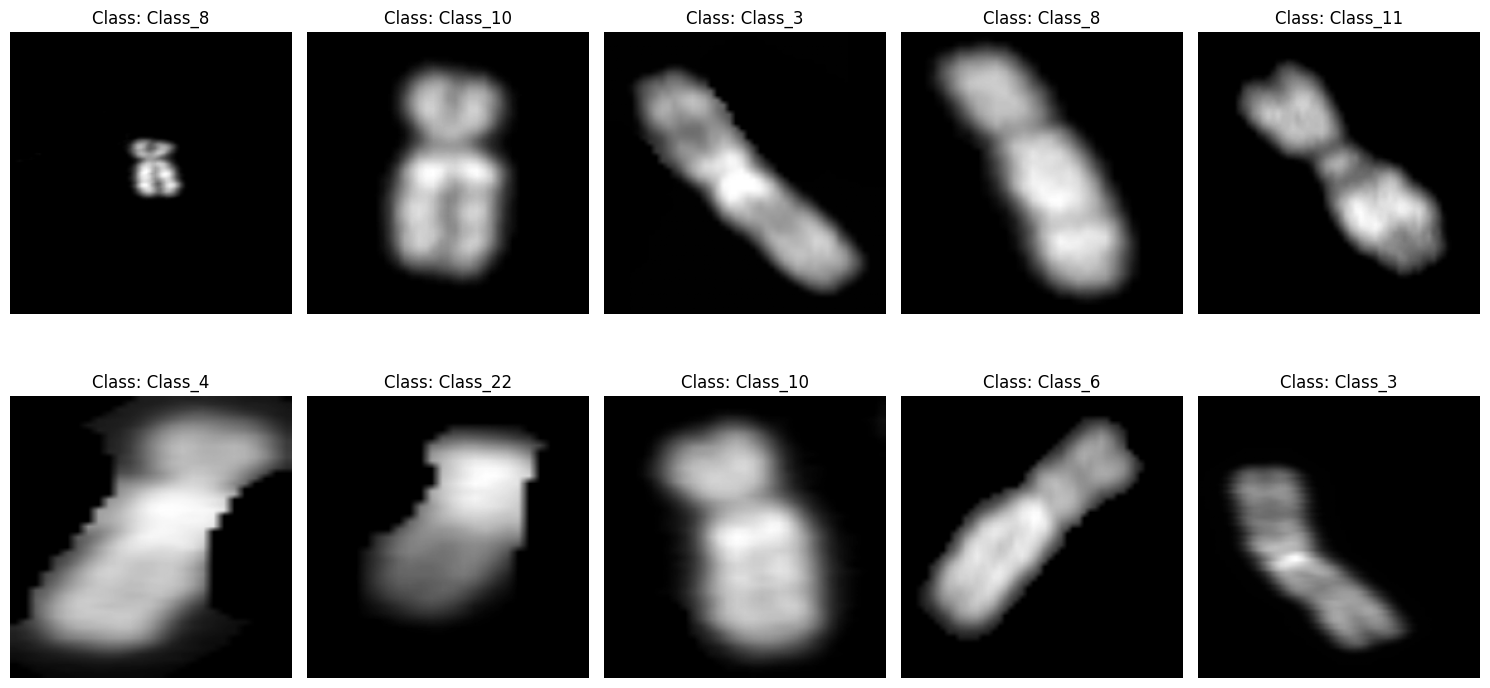

In [45]:
# ============================================================
# 8. VISUALIZE ORIGINAL IMAGES
# ============================================================

plt.figure(figsize=(15, 8))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Class: {class_names[y_train[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

#Preprocessing


In [46]:
# ============================================================
# 9. PREPROCESSING SETUP
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV version:", cv2.__version__)
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

OpenCV version: 5.0.0
Train: (3831, 224, 224)
Validation: (821, 224, 224)
Test: (822, 224, 224)


#Cropping

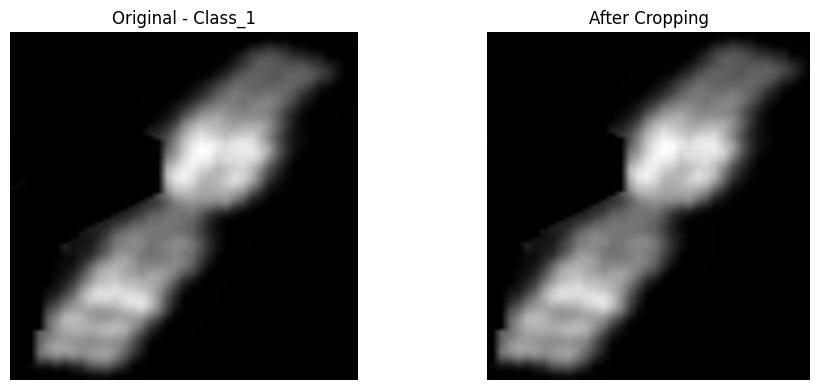

Original shape : (224, 224)
Cropped shape  : (222, 206)
Original mean  : 22.477359693877553
Cropped mean   : 24.644209743724307


In [52]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CROPPING
# ============================================================

def crop_chromosome(image, threshold=10, padding=5):

    # Find chromosome pixels
    coords = np.argwhere(image > threshold)

    # If no foreground found
    if len(coords) == 0:
        return image

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    # Add padding
    y_min = max(0, y_min - padding)
    x_min = max(0, x_min - padding)
    y_max = min(image.shape[0], y_max + padding + 1)
    x_max = min(image.shape[1], x_max + padding + 1)

    return image[y_min:y_max, x_min:x_max]


# Select one chromosome
idx = 0

original = images[idx]
cropped = crop_chromosome(original)


# ============================================================
# VISUALIZE
# ============================================================

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(original, cmap="gray")
plt.title(f"Original - {class_names[labels[idx]]}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cropped, cmap="gray")
plt.title("After Cropping")
plt.axis("off")

plt.tight_layout()
plt.show()


print("Original shape :", original.shape)
print("Cropped shape  :", cropped.shape)

print("Original mean  :", original.mean())
print("Cropped mean   :", cropped.mean())

#Scaling / Resizing

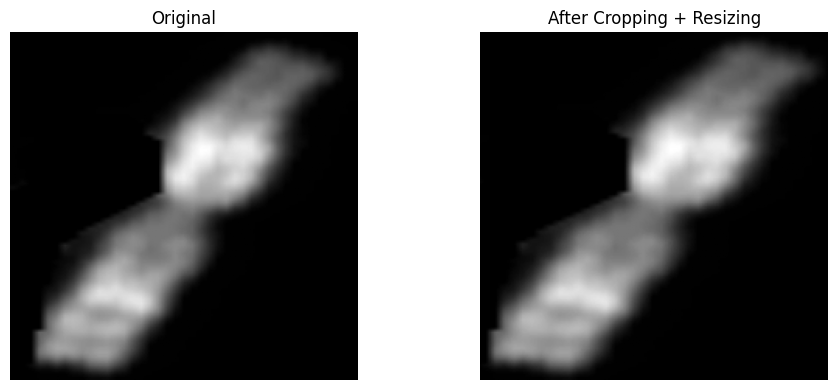

Original shape : (224, 224)
Cropped shape  : (222, 206)
Resized shape  : (224, 224)


In [53]:
import cv2
import matplotlib.pyplot as plt

# ============================================================
# SCALING / RESIZING
# ============================================================

target_size = (224, 224)

resized = cv2.resize(
    cropped,
    target_size,
    interpolation=cv2.INTER_AREA
)


# ============================================================
# VISUALIZE
# ============================================================

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(original, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(resized, cmap="gray")
plt.title("After Cropping + Resizing")
plt.axis("off")

plt.tight_layout()
plt.show()


print("Original shape :", original.shape)
print("Cropped shape  :", cropped.shape)
print("Resized shape  :", resized.shape)

#Rotation & Alighment

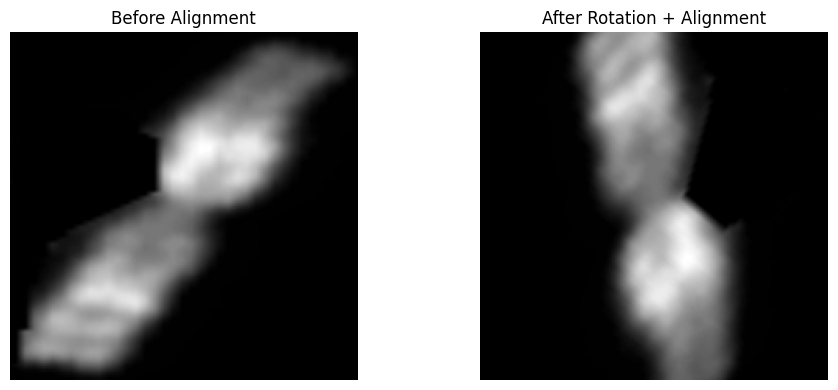

In [54]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# ============================================================
# ROTATION / ALIGNMENT
# ============================================================

def align_chromosome(image, threshold=10):

    # Find chromosome pixels
    ys, xs = np.where(image > threshold)

    if len(xs) < 2:
        return image

    points = np.column_stack((xs, ys)).astype(np.float32)

    # PCA
    mean, eigenvectors = cv2.PCACompute(points, mean=None)

    # Main orientation
    angle = np.degrees(
        np.arctan2(
            eigenvectors[0, 1],
            eigenvectors[0, 0]
        )
    )

    # Rotate to horizontal reference orientation
    rotation_angle = -angle

    h, w = image.shape

    center = (w // 2, h // 2)

    matrix = cv2.getRotationMatrix2D(
        center,
        rotation_angle,
        1.0
    )

    aligned = cv2.warpAffine(
        image,
        matrix,
        (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0
    )

    return aligned


aligned = align_chromosome(resized)


# ============================================================
# VISUALIZE
# ============================================================

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(resized, cmap="gray")
plt.title("Before Alignment")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(aligned, cmap="gray")
plt.title("After Rotation + Alignment")
plt.axis("off")

plt.tight_layout()
plt.show()

#Exposure adjustment

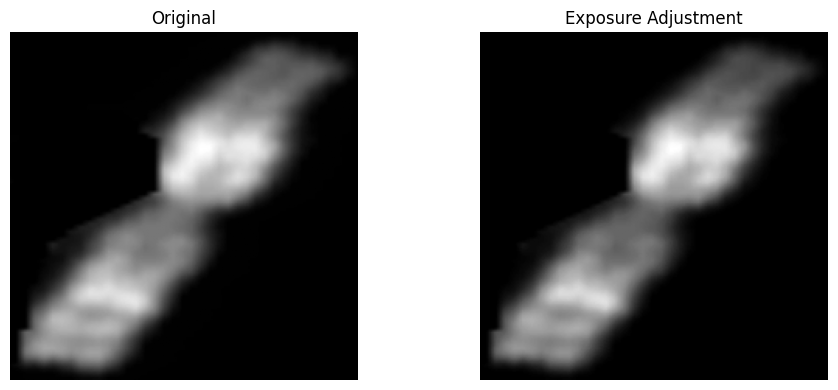

Original mean : 24.59442761479592
Adjusted mean : 18.958187181122447


In [55]:
# ============================================================
# EXPOSURE / BRIGHTNESS ADJUSTMENT
# ============================================================

def adjust_exposure(image, gamma=1.2):

    image_float = image.astype(np.float32) / 255.0

    adjusted = np.power(image_float, gamma)

    adjusted = np.clip(adjusted * 255, 0, 255)

    return adjusted.astype(np.uint8)


exposure = adjust_exposure(resized, gamma=1.2)


# ============================================================
# VISUALIZE
# ============================================================

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(resized, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(exposure, cmap="gray")
plt.title("Exposure Adjustment")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Original mean :", resized.mean())
print("Adjusted mean :", exposure.mean())

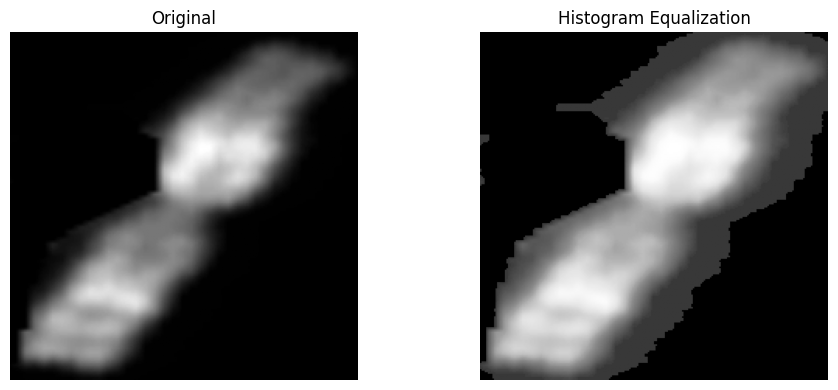

In [56]:
# ============================================================
# HISTOGRAM EQUALIZATION
# ============================================================

hist_equalized = cv2.equalizeHist(resized)


# ============================================================
# VISUALIZE
# ============================================================

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(resized, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hist_equalized, cmap="gray")
plt.title("Histogram Equalization")
plt.axis("off")

plt.tight_layout()
plt.show()

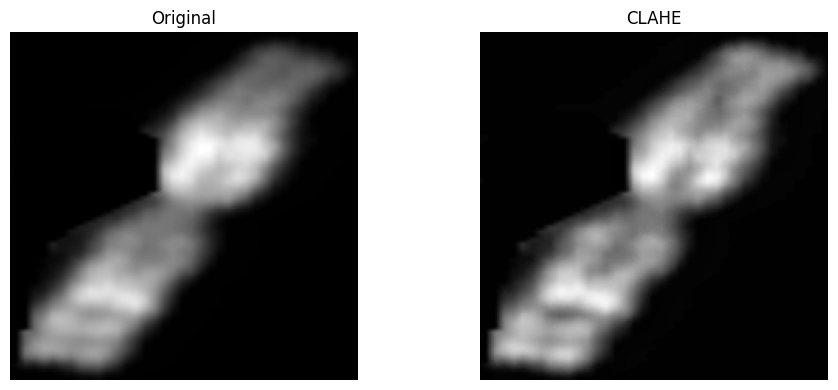

In [57]:
# ============================================================
# CLAHE
# ============================================================

clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

clahe_image = clahe.apply(resized)


# ============================================================
# VISUALIZE
# ============================================================

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(resized, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(clahe_image, cmap="gray")
plt.title("CLAHE")
plt.axis("off")

plt.tight_layout()
plt.show()

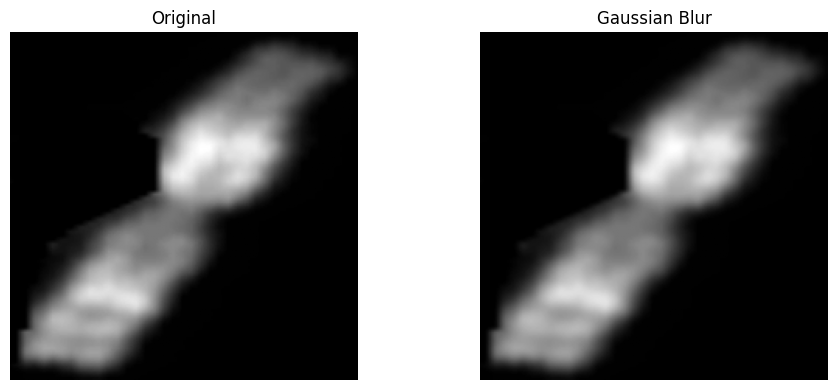

In [58]:
# ============================================================
# GAUSSIAN NOISE REDUCTION
# ============================================================

gaussian = cv2.GaussianBlur(
    resized,
    (5, 5),
    0
)


plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(resized, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(gaussian, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off")

plt.tight_layout()
plt.show()

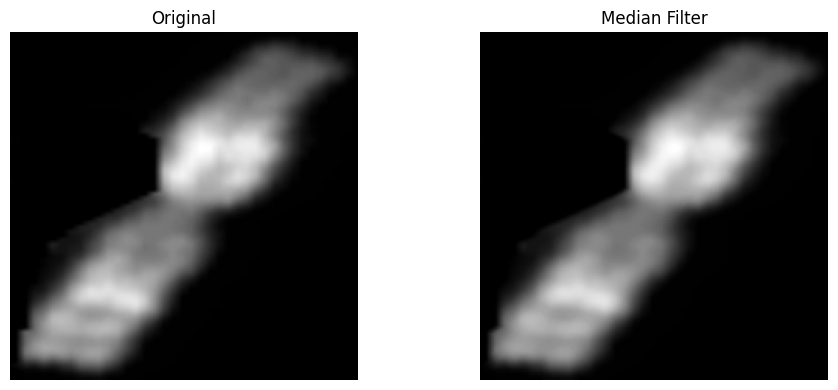

In [59]:
# ============================================================
# MEDIAN NOISE REDUCTION
# ============================================================

median = cv2.medianBlur(
    resized,
    5
)


plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(resized, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(median, cmap="gray")
plt.title("Median Filter")
plt.axis("off")

plt.tight_layout()
plt.show()

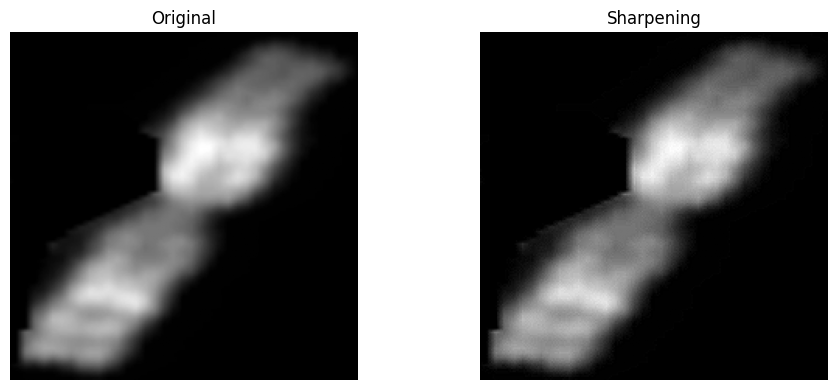

In [60]:
# ============================================================
# SHARPENING
# ============================================================

kernel = np.array([
    [0, -1,  0],
    [-1, 5, -1],
    [0, -1,  0]
])

sharpened = cv2.filter2D(
    resized,
    -1,
    kernel
)


# ============================================================
# VISUALIZE
# ============================================================

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(resized, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sharpened, cmap="gray")
plt.title("Sharpening")
plt.axis("off")

plt.tight_layout()
plt.show()

Images: (5474, 224, 224)
Labels: (5474,)
Classes: 24
Selected indices: [np.int64(0), np.int64(238), np.int64(476), np.int64(714), np.int64(952), np.int64(1190), np.int64(1428), np.int64(1666), np.int64(1904), np.int64(2142), np.int64(2380), np.int64(2618)]
Selected labels: [ 0  1  2  3  4  5  6  7  8  9 10 11]


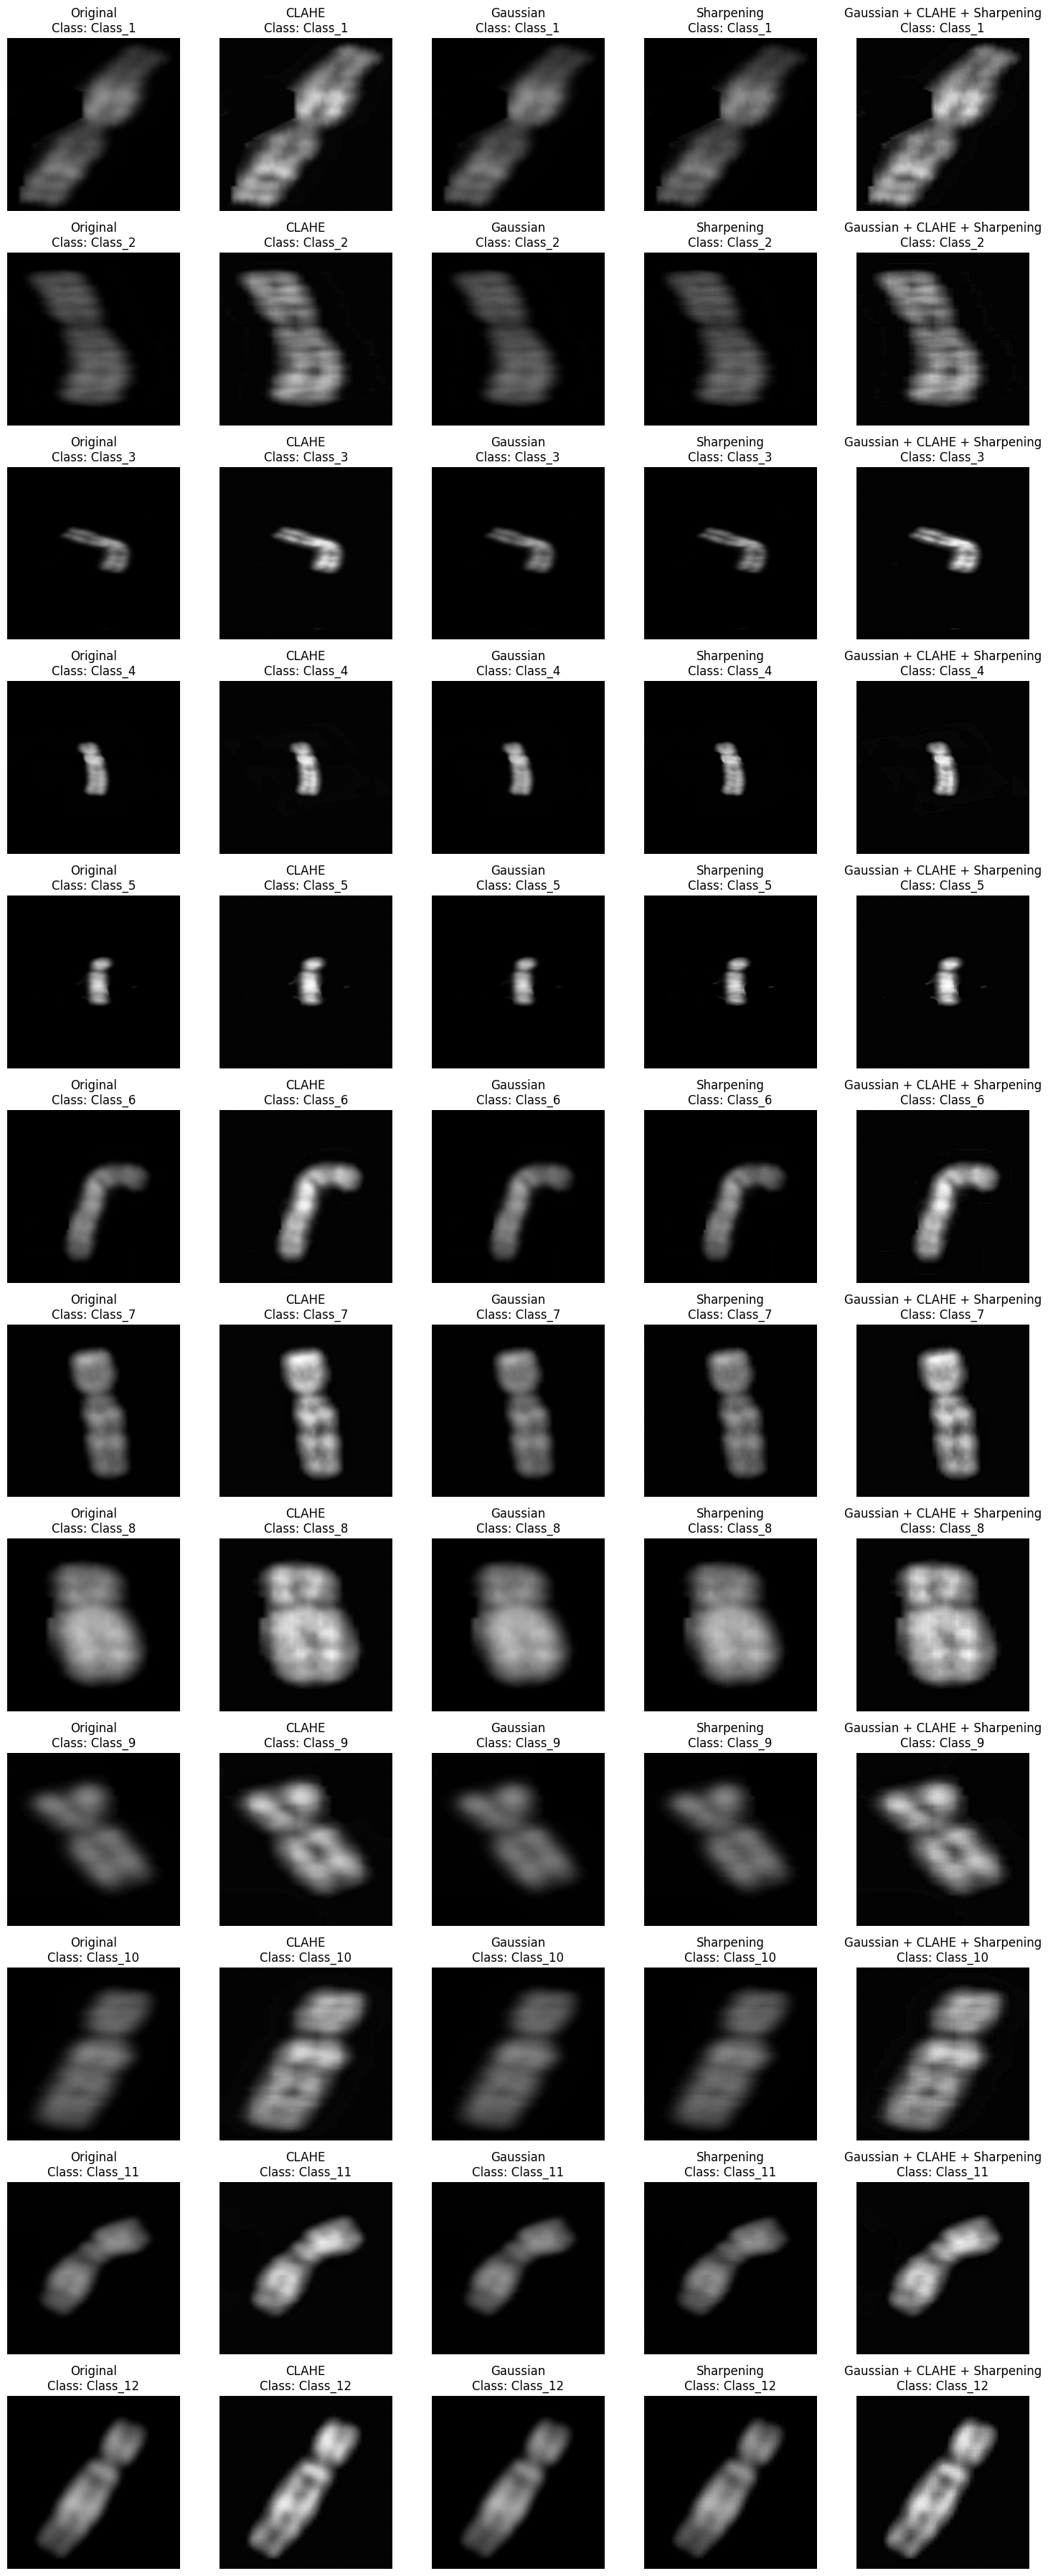

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# ============================================================
# CHECK DATA
# ============================================================

print("Images:", images.shape)
print("Labels:", labels.shape)
print("Classes:", len(class_names))

# ------------------------------------------------------------
# Select 12 DIFFERENT images from different classes
# ------------------------------------------------------------

sample_indices = []

for class_id in range(min(12, len(class_names))):
    idx = np.where(labels == class_id)[0]

    if len(idx) > 0:
        sample_indices.append(idx[0])

print("Selected indices:", sample_indices)
print("Selected labels:", labels[sample_indices])

# ============================================================
# PREPROCESSING FUNCTIONS
# ============================================================

def clahe(img):
    img = img.astype(np.uint8)

    clahe_obj = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    return clahe_obj.apply(img)


def gaussian(img):
    return cv2.GaussianBlur(
        img,
        (3, 3),
        0
    )


def sharpening(img):
    kernel = np.array([
        [0, -1,  0],
        [-1, 5, -1],
        [0, -1,  0]
    ])

    return cv2.filter2D(
        img,
        -1,
        kernel
    )


def gaussian_clahe_sharpen(img):

    x = gaussian(img)
    x = clahe(x)
    x = sharpening(x)

    return x


# ============================================================
# VISUALIZE DIFFERENT CHROMOSOMES
# ============================================================

fig, axes = plt.subplots(
    len(sample_indices),
    5,
    figsize=(15, 3 * len(sample_indices))
)

for row, idx in enumerate(sample_indices):

    img = images[idx].astype(np.uint8)

    processed = [
        img,
        clahe(img),
        gaussian(img),
        sharpening(img),
        gaussian_clahe_sharpen(img)
    ]

    titles = [
        "Original",
        "CLAHE",
        "Gaussian",
        "Sharpening",
        "Gaussian + CLAHE + Sharpening"
    ]

    for col in range(5):

        axes[row, col].imshow(
            processed[col],
            cmap="gray",
            vmin=0,
            vmax=255
        )

        axes[row, col].set_title(
            f"{titles[col]}\nClass: {class_names[labels[idx]]}"
        )

        axes[row, col].axis("off")

plt.tight_layout()
plt.show()